In [1]:
import torch
import torch.nn as nn
import math
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")

Utilisation de : cuda


In [2]:
# On choisit une taille standard, par exemple 128x128
IMG_SIZE = 128

# Transformations pour les images
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def apply_transforms(examples):
    # On applique la transformation à chaque image du batch
    examples["pixel_values"] = [transform(img.convert("RGB")) for img in examples["image"]]
    return examples

In [3]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

# Chemin vers ton dossier local
DATA_DIR = "Vehicles"     # <-- adapte si besoin
IMG_SIZE = 128
BATCH_SIZE = 32
SEED = 0
NUM_CLASSES = 7

# Transforms (identiques à ton idée actuelle)
transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),  # <-- AJOUT
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

# Dataset local (classe = nom du sous-dossier)
full_ds = ImageFolder(root=DATA_DIR, transform=transform)

# Classes
print("Classes:", full_ds.classes)
print("NUM_CLASSES:", NUM_CLASSES)

# Split 80/10/10
torch.manual_seed(SEED)
n = len(full_ds)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test])

Classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']
NUM_CLASSES: 7


In [4]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Sanity check
images, labels = next(iter(train_loader))
print("Batch images:", images.shape)          # (B, 3, IMG_SIZE, IMG_SIZE)
print("Labels range:", labels.min().item(), labels.max().item())  # doit être 0..NUM_CLASSES-1

Batch images: torch.Size([32, 3, 128, 128])
Labels range: 0 6


In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, hidden_dim=128):
        super().__init__()
        self.patch_size = patch_size
        # On utilise une convolution pour extraire les patchs et les projeter
        self.projection = nn.Conv2d(in_channels, hidden_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        # x: (batch, 3, height, width)
        x = self.projection(x) # (batch, hidden_dim, h_patch, w_patch)
        x = x.flatten(2) # (batch, hidden_dim, num_patches)
        x = x.transpose(1, 2) # (batch, num_patches, hidden_dim)
        return x

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,  # (B, T, D) comme ton code
        )

    def forward(self, q, k, v, mask=None):
        # Pour un ViT, mask=None suffit dans 99% des cas
        # Si tu veux gérer un mask plus tard, on l'ajoute.
        out, _ = self.mha(q, k, v, need_weights=False)
        return out


In [7]:
class LayerNorm(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.eps = 1e-5 # small value to avoid division by zero
        self.scale = nn.Parameter(torch.ones(hidden_dim)) # scale parameter (learnable)
        self.shift = nn.Parameter(torch.zeros(hidden_dim)) # shift parameter (learnable)

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        y = self.scale * norm_x + self.shift
        return y

In [8]:
class FeedForward(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.ReLU(),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )

    def forward(self, x):
        return self.layers(x)

In [9]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads, dropout=0.0):
        super().__init__()
        self.attention = MultiHeadAttention(hidden_dim, num_heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.feed_forward = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),                 # GELU plutôt que ReLU pour ViT
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attention(self.norm1(x), self.norm1(x), self.norm1(x), mask=None)
        x = x + self.feed_forward(self.norm2(x))
        return x


In [10]:
class VisionTransformer(nn.Module):
    def __init__(self, patch_size, hidden_dim, num_heads, num_layers, num_classes,
                 img_size=32, dropout=0.2):
        super().__init__()
        self.patch_embedding = PatchEmbedding(patch_size=patch_size, hidden_dim=hidden_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))

        num_patches = (img_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, hidden_dim))

        self.pos_dropout = nn.Dropout(dropout)   # <-- AJOUT

        self.transformer = nn.Sequential(*[
            TransformerEncoderBlock(hidden_dim, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.patch_embedding(x)
        B = x.shape[0]

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embedding
        x = self.pos_dropout(x)                  # <-- AJOUT
        x = self.transformer(x)

        return self.classifier(x[:, 0])


In [11]:
class VGG16CNN(nn.Module):
    """
    VGG16-style CNN codé à la main.
    Pour IMG_SIZE=128, après 5 MaxPool2d(2): 128 -> 64 -> 32 -> 16 -> 8 -> 4
    Donc la carte finale est (512, 4, 4).
    """
    def __init__(self, num_classes, img_size=128, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 128 -> 64
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 64 -> 32
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 32 -> 16
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4: 16 -> 8
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5: 8 -> 4
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # taille finale spatiale après 5 pools
        feat_size = img_size // (2**5)  # 128//32 = 4
        feat_dim = 512 * feat_size * feat_size

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 4096), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, 4096), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc = 0.0, 0.0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()   # IMPORTANT

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)

        # DEBUG SAFE GUARD (à laisser le temps de corriger)
        if outputs.ndim != 2:
            raise ValueError(f"outputs should be (B, C), got {outputs.shape}")
        C = outputs.size(1)
        if labels.min().item() < 0 or labels.max().item() >= C:
            raise ValueError(
                f"Label out of range for CrossEntropy: "
                f"min={labels.min().item()}, max={labels.max().item()}, C={C}"
            )

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += (outputs.argmax(1) == labels).float().mean().item()

    return total_loss / len(dataloader), total_acc / len(dataloader)


In [17]:
import matplotlib.pyplot as plt

def plot_vit_vs_cnn(results, title=""):
    epochs = range(1, len(results["vit"]["train_loss"]) + 1)

    # --- Loss ---
    plt.figure()
    plt.plot(epochs, results["vit"]["train_loss"], label="ViT train loss")
    plt.plot(epochs, results["vit"]["val_loss"],   label="ViT val loss")
    plt.plot(epochs, results["cnn"]["train_loss"], label="CNN train loss")
    plt.plot(epochs, results["cnn"]["val_loss"],   label="CNN val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss — {title}" if title else "Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Accuracy ---
    plt.figure()
    plt.plot(epochs, results["vit"]["train_acc"], label="ViT train acc")
    plt.plot(epochs, results["vit"]["val_acc"],   label="ViT val acc")
    plt.plot(epochs, results["cnn"]["train_acc"], label="CNN train acc")
    plt.plot(epochs, results["cnn"]["val_acc"],   label="CNN val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy — {title}" if title else "Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [14]:
# Paramètres
HIDDEN_DIM = 128
NUM_HEADS = 8
PATCH_SIZE = 16 # Pour 128x128, 16 est un bon compromis

# Initialisation
vit_model = VisionTransformer(
    patch_size=PATCH_SIZE, 
    hidden_dim=HIDDEN_DIM, 
    num_heads=NUM_HEADS, 
    num_layers=4, 
    num_classes=NUM_CLASSES, 
    img_size=IMG_SIZE,
    dropout=0.2
).to(device)

cnn_model = VGG16CNN(num_classes=NUM_CLASSES).to(device)

# Exemple de configuration d'entraînement
optimizer_vit = torch.optim.AdamW(vit_model.parameters(), lr=1e-4)
optimizer_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

print("Modèles prêts pour l'entraînement !")

Modèles prêts pour l'entraînement !


In [15]:

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_acc = 0.0, 0.0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        total_acc += (outputs.argmax(1) == labels).float().mean().item()

    return total_loss / len(dataloader), total_acc / len(dataloader)


In [16]:
EPOCHS = 10
results = {
    "vit": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
    "cnn": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
}

for epoch in range(EPOCHS):
    # ---- ViT ----
    vit_train_loss, vit_train_acc = train_epoch(vit_model, train_loader, optimizer_vit, criterion, device)
    vit_val_loss,   vit_val_acc   = evaluate(vit_model, val_loader, criterion, device)

    results["vit"]["train_loss"].append(vit_train_loss)
    results["vit"]["train_acc"].append(vit_train_acc)
    results["vit"]["val_loss"].append(vit_val_loss)
    results["vit"]["val_acc"].append(vit_val_acc)

    # ---- CNN ----
    cnn_train_loss, cnn_train_acc = train_epoch(cnn_model, train_loader, optimizer_cnn, criterion, device)
    cnn_val_loss,   cnn_val_acc   = evaluate(cnn_model, val_loader, criterion, device)

    results["cnn"]["train_loss"].append(cnn_train_loss)
    results["cnn"]["train_acc"].append(cnn_train_acc)
    results["cnn"]["val_loss"].append(cnn_val_loss)
    results["cnn"]["val_acc"].append(cnn_val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"ViT: train acc {vit_train_acc:.2f} val acc {vit_val_acc:.2f} || "
        f"CNN: train acc {cnn_train_acc:.2f} val acc {cnn_val_acc:.2f}"
    )


/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10 | ViT: train acc 0.34 val acc 0.44 || CNN: train acc 0.14 val acc 0.14


/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2/10 | ViT: train acc 0.47 val acc 0.54 || CNN: train acc 0.14 val acc 0.12


/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 8/10 | ViT: train acc 0.63 val acc 0.64 || CNN: train acc 0.55 val acc 0.54


/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 9/10 | ViT: train acc 0.65 val acc 0.65 || CNN: train acc 0.61 val acc 0.62


/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/fonsecag/.conda/envs/HDDLtorch/lib/python3.12/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10/10 | ViT: train acc 0.67 val acc 0.65 || CNN: train acc 0.66 val acc 0.66


In [40]:
torch.save(vit_model.state_dict(), "20_epochs_vit_vehicles.pth")
torch.save(cnn_model.state_dict(), "20_epochs_vgg16_vehicles.pth")

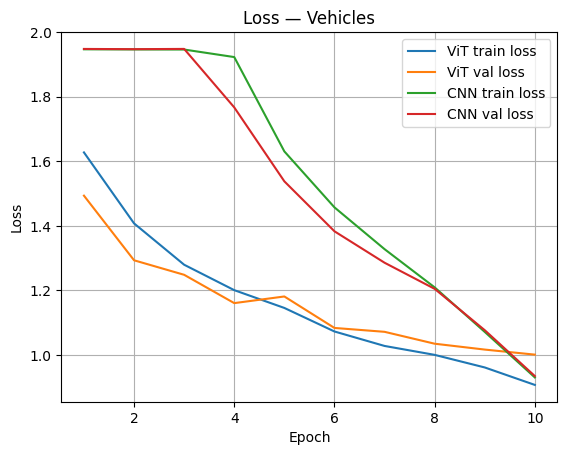

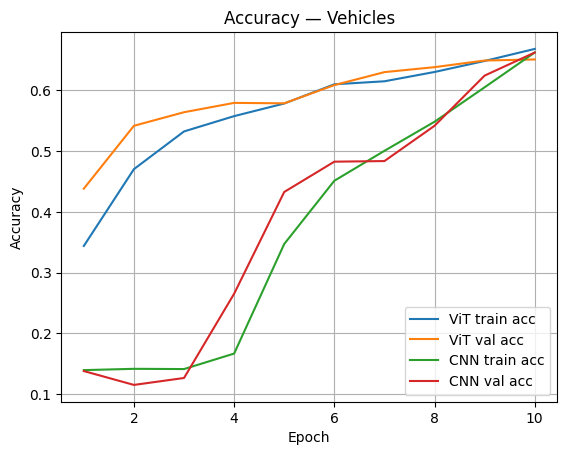

In [18]:
plot_vit_vs_cnn(results, title="Vehicles")